<!-- WARNING: THIS FILE WAS AUTOGENERATED! DO NOT EDIT! -->

In [ ]:
from bioMONAI.data import *
from bioMONAI.transforms import *
from fastai.vision.all import *
from monai.utils import set_determinism

In [ ]:
torch.cuda.get_device_name(0)

'Quadro RTX 4000'

In [ ]:
bs, size = 8, 2048
# arch = models.resnet34
path = Path('../../bioMONAI_0/_data/Thunder_20230308/nuevos_datos/dataset')
#path = Path('../_data/Babesia/')
path_x = path/'inputs'
path_y = path/'targets'

In [ ]:
from bioMONAI.core import get_target
get_target(path_y, same_filename=True)(path / 'sample_1.png')

Path('../../bioMONAI_0/_data/Thunder_20230308/nuevos_datos/dataset/targets/sample_1.png')

In [ ]:
from bioMONAI.core import get_target
from bioMONAI.transforms import RandCrop2D
from bioMONAI.transforms import RandCropND
from monai.transforms import ScaleIntensity

dblock = DataBlock(blocks=(ImageBlock(cls=PILImageBW), ImageBlock(cls=PILImageBW)),
                   get_items=get_image_files,
                   get_y=get_target(path_y, same_filename=True),
                   splitter=RandomSplitter(valid_pct=0.2),
                   item_tfms=[RandomCrop(256),FlipItem(0.5)],
                  )

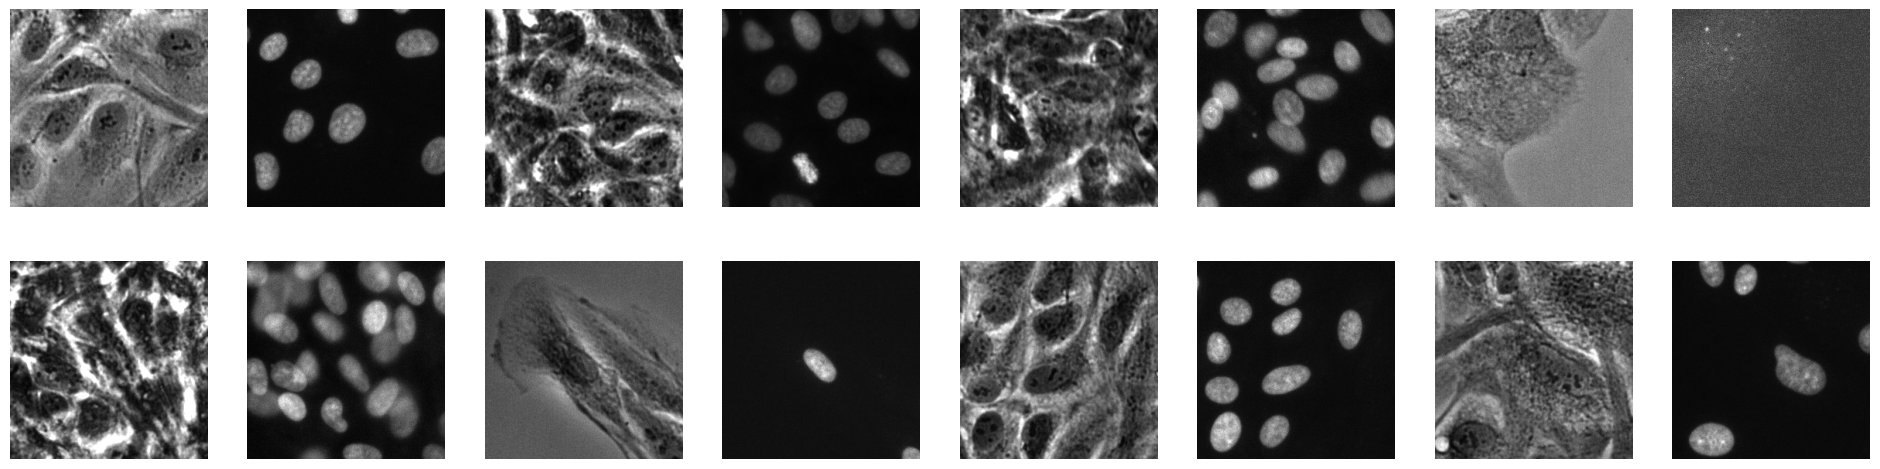

In [ ]:
dls = dblock.dataloaders(path_x, bs=bs)
dls.show_batch(max_n=8, cmap='gray')

In [ ]:
inputs, targets = dls.one_batch()
print(f'Inputs shape: {inputs.shape}, Targets shape: {targets.shape}')

# Asegúrate de que las dimensiones de entrada y salida sean las mismas
assert inputs.shape == targets.shape, "Dimensiones de entrada y salida no coinciden"

Inputs shape: torch.Size([8, 1, 256, 256]), Targets shape: torch.Size([8, 1, 256, 256])


In [ ]:
from monai.networks.nets import BasicUNet, UNet, AttentionUnet, DynUNet, UNet, BasicUNet, UNETR

In [ ]:
# Definir el modelo U-Net

# model = BasicUNet(spatial_dims=2, in_channels=1, out_channels=1)

#model = unet_learner(dls, resnet34, n_out=3, loss_func=MSELossFlat())

#model = cnn_learner(dls, resnet18,n_out=1, metrics=accuracy)

#model = UNet(spatial_dims=2, in_channels=1, out_channels=1, channels=(32, 64, 128, 256),strides=(1, 1, 1), num_res_units=1).model

# model = AttentionUnet(spatial_dims=2, in_channels=1, out_channels=1, channels=(16, 32, 64),strides=(1, 1))
# model = DynUNet(spatial_dims=2, in_channels=1, out_channels=1, strides=(1, 2, 2),kernel_size=(3, 3, 3), upsample_kernel_size=(2, 2), res_block=True) # it tends to create hot pixels

model = UNETR(in_channels=1, out_channels=1, img_size=1024, spatial_dims=2)

OptionalImportError: from einops.layers.torch import Rearrange (No module named 'einops').

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/latest/installation.html#installing-the-recommended-dependencies

In [ ]:
# learn = unet_learner(dls, resnet34, n_out=3, loss_func=MSELossFlat())
# learn.fine_tune(20)

In [ ]:
from bioMONAI.losses import CombinedLoss
loss_func = mse #CombinedLoss()

In [ ]:
from bioMONAI.losses import SSIMMetric

metrics = [mae, mse, SSIMMetric]

In [ ]:
learn = Learner(dls, model, loss_func=loss_func, metrics=SSIMMetric, cbs=ShowGraphCallback())

epoch,train_loss,valid_loss,SSIM,time
0,0.134428,0.068712,-0.062993,00:02
1,0.087141,0.049722,-0.084752,00:02
2,0.066057,0.037253,-0.138284,00:02
3,0.052756,0.036632,-0.125318,00:02
4,0.044291,0.038815,-0.118946,00:02
5,0.037966,0.039524,-0.114948,00:02
6,0.033131,0.041148,-0.105955,00:02
7,0.029206,0.046223,-0.078393,00:02
8,0.026071,0.050194,-0.071779,00:02
9,0.023577,0.047164,-0.044615,00:02


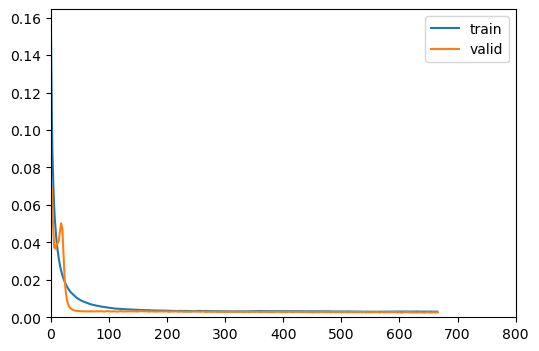

KeyboardInterrupt: 

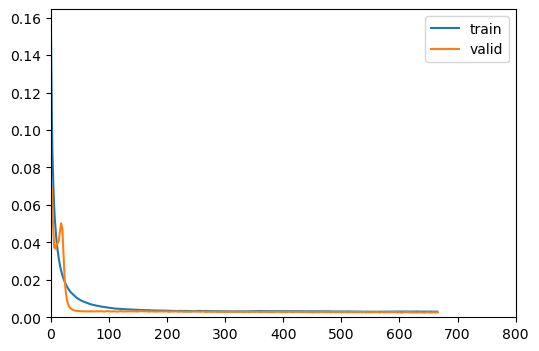

In [ ]:
learn.fit(400)

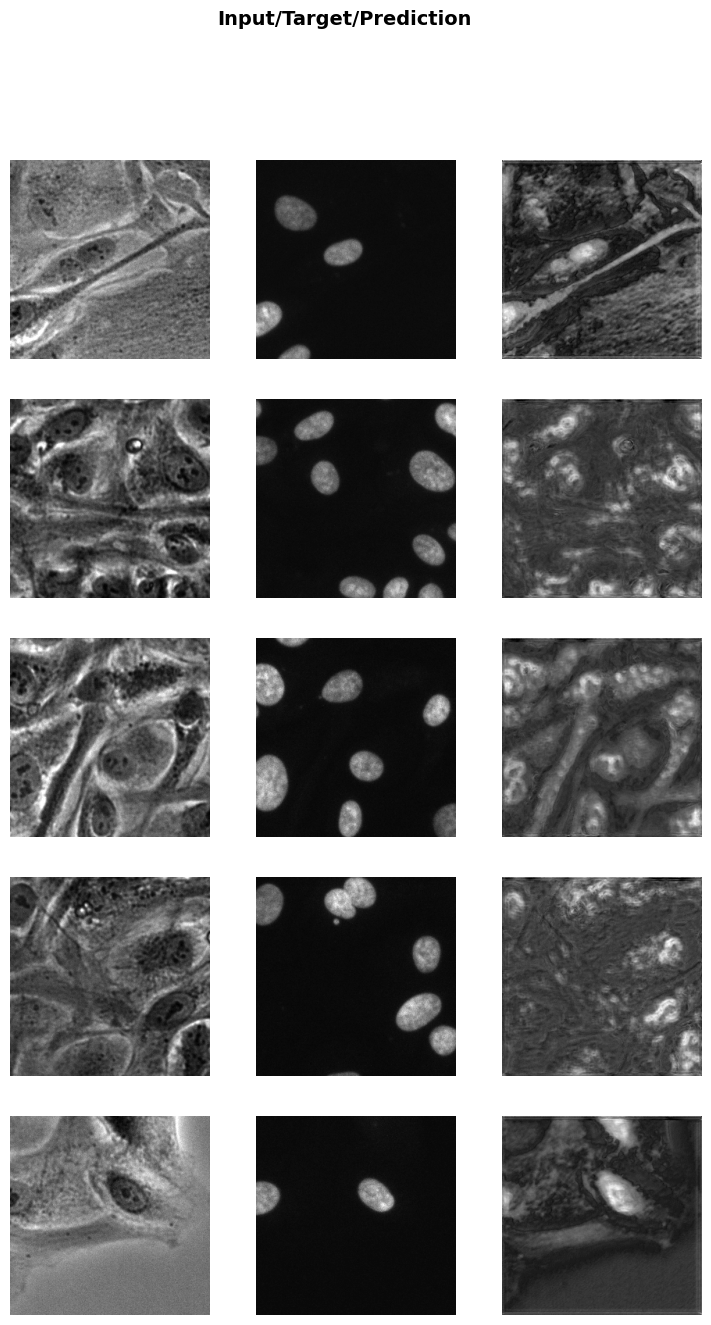

In [ ]:
learn.show_results(cmap='gray')

In [ ]:
image_path = '../../bioMONAI_0/_data/Thunder_20230308/nuevos_datos/dataset/test/sample_29.png'


image = Image.open(image_path).convert('L')

array = np.array(image)

array = array[256:512,256:512]

tensor = tensor1 = torch.from_numpy(array)

tensor = tensor.unsqueeze(0).unsqueeze(0)

tensor = tensor/255.0

print(tensor.shape)

tensor = tensor.to('cuda')

torch.Size([1, 1, 256, 256])


In [ ]:
model = model.to('cuda')
output_tensor = model(tensor.to('cuda'))

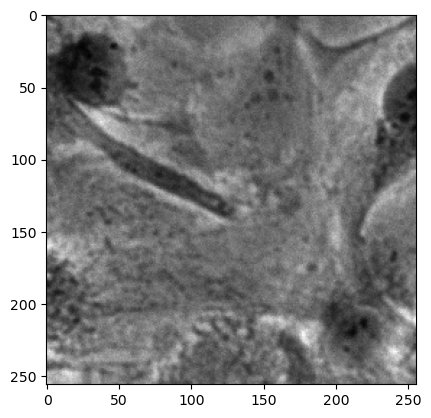

In [ ]:
plt.imshow(array[:,:], cmap='gray')
plt.show()

In [ ]:
# Convertir el tensor de PyTorch a un arreglo de numpy

output_tensor = output_tensor.cpu()
output_array = output_tensor.detach().numpy()

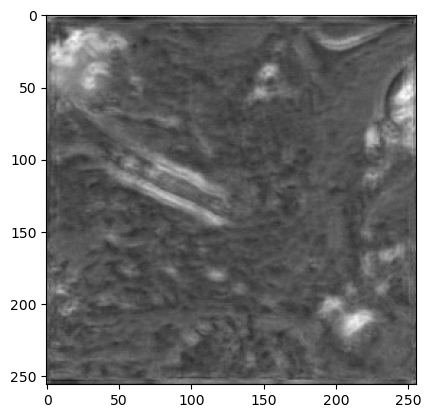

In [ ]:
plt.imshow(output_array.squeeze((0,1)), cmap='gray')
plt.show()

In [ ]:
image_path = '../../bioMONAI_0/_data/Thunder_20230308/nuevos_datos/dataset/test/sample_29_target.png'


image = Image.open(image_path).convert('L')

array = np.array(image)

array = array[256:512,256:512]

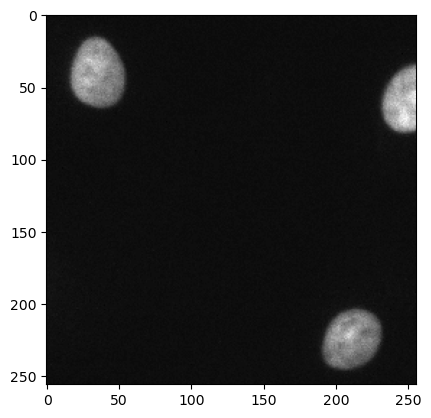

In [ ]:
plt.imshow(array[:,:], cmap='gray')
plt.show()